# Further work with modelgrids

First we load the libraries.

In [4]:
import os
import sys
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import flopy
from flopy.discretization import StructuredGrid, UnstructuredGrid, VertexGrid

print(sys.version)
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {mpl.__version__}")
print(f"flopy version: {flopy.__version__}")

3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
numpy version: 2.2.5
matplotlib version: 3.10.3
flopy version: 3.9.5


We then define the model grid.

In [5]:
xll = 3579
yll = 10000
rotation = 0

nrow = 40
ncol = 20
nlay = 1
Lx = 4000
Ly = 8000

# create delr and delc arrays
delr = np.ones((ncol,)) * (Lx / ncol)
delc = np.ones((nrow,)) * (Ly / nrow)

# create a sloped top and bottom
slope = np.linspace(100, 0, nrow)
slope.shape = (1, nrow)

top = np.ones((nrow, ncol)) * slope.T
botm = np.ones((nlay, nrow, ncol)) * (top - 100)

# create an ibound array
ibound = np.ones((nrow, ncol), dtype=int)
ibound[-1, 0:5] = 0
ibound[-1, 15:] = 0


modelgrid = StructuredGrid(
    delr=delr,
    delc=delc,
    top=top,
    botm=botm,
    idomain=ibound,
    nlay=nlay,
    xoff=xll,
    yoff=yll,
    angrot=rotation,
)
modelgrid

xll:3579; yll:10000; rotation:0; units:undefined; lenuni:0

We can now plot the modelgrid.

Text(0.5, 1.0, 'Top elevations and Ibound from StructuredGrid')

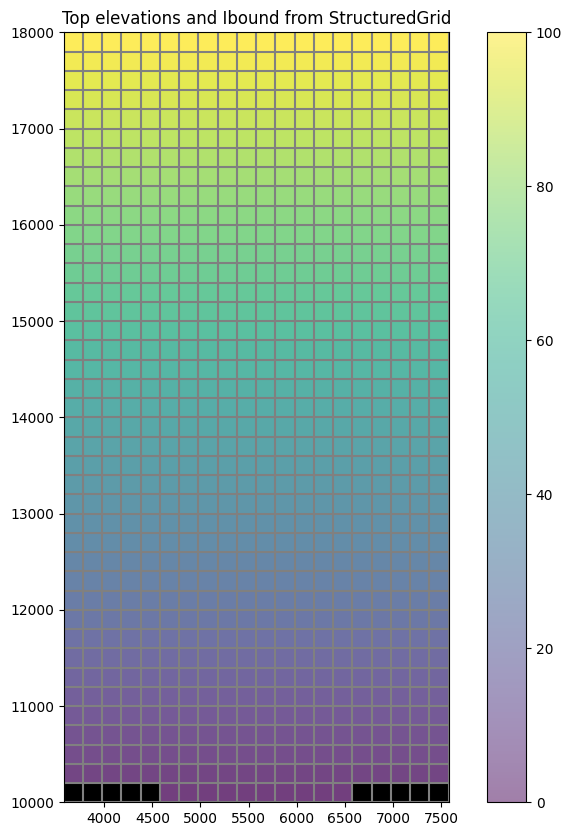

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

pmv = flopy.plot.PlotMapView(modelgrid=modelgrid)
pc = pmv.plot_array(modelgrid.top, alpha=0.5)
pmv.plot_grid()
pmv.plot_ibound()

plt.colorbar(pc)
ax.set_title("Top elevations and Ibound from StructuredGrid")

## Plotting cross-sections

Cross-sections can be plotted at given coordinates.

Text(0.5, 1.0, 'Cross-Section of StructuredGrid')

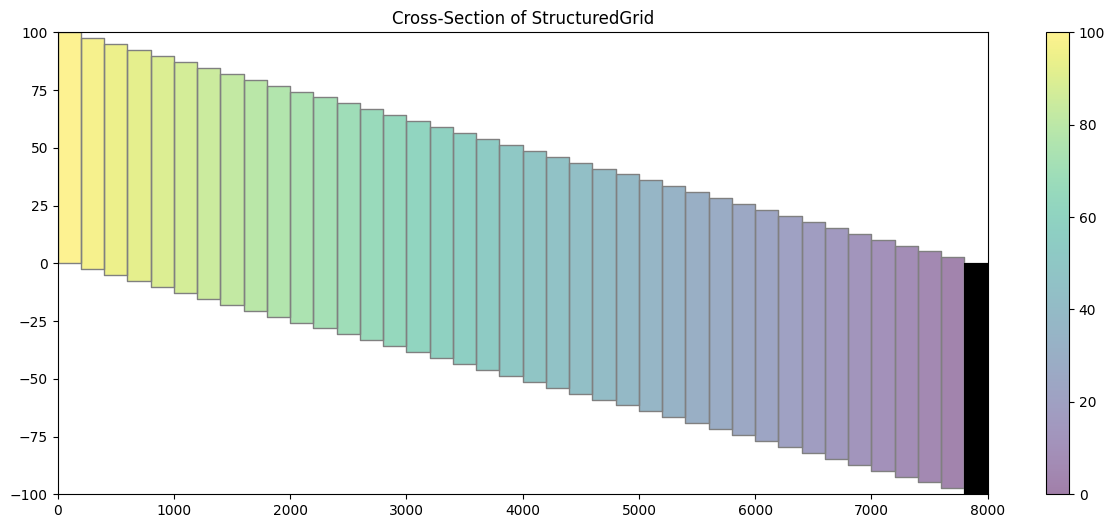

In [7]:
col = 4

figure, ax = plt.subplots(figsize=(15, 6))

xc = flopy.plot.PlotCrossSection(modelgrid=modelgrid, line={"column": col})
pc = xc.plot_array(modelgrid.top, alpha=0.5)
xc.plot_grid()
xc.plot_ibound()

plt.colorbar(pc)
plt.title("Cross-Section of StructuredGrid")